# Data Pre-processing


In [ ]:
import os
import shutil
import random
import yaml
import kagglehub
from tqdm import tqdm

# Download dataset and capture the dynamic Colab path
dataset_path = kagglehub.dataset_download("smaildurcan/turkish-license-plate-dataset")
print(f"Dataset downloaded to: {dataset_path}")

# Define Colab-friendly paths
input_img_path = os.path.join(dataset_path, 'images')
input_label_path = os.path.join(dataset_path, 'label')
output_base_dir = '/content/license_plate_data'

# Create YOLO directories
sub_dirs = ['images/train', 'images/val', 'labels/train', 'labels/val']
for sub_dir in sub_dirs:
    os.makedirs(os.path.join(output_base_dir, sub_dir), exist_ok=True)

# File Listing and Splitting
all_images = [f for f in os.listdir(input_img_path) if f.endswith(('.jpg', '.jpeg', '.png'))]
random.seed(42)
random.shuffle(all_images)

split_idx = int(len(all_images) * 0.9)
train_images = all_images[:split_idx]
val_images = all_images[split_idx:]

def process_data(image_list, split_type):
    print(f"Copying {split_type} data...")
    for img_name in tqdm(image_list):
        base_name = os.path.splitext(img_name)[0]

        src_img = os.path.join(input_img_path, img_name)
        # Check standard YOLO label location first, then fallback to 'label' folder
        src_txt = os.path.join(input_img_path, base_name + '.txt')
        if not os.path.exists(src_txt):
            src_txt = os.path.join(input_label_path, base_name + '.txt')

        dst_img = os.path.join(output_base_dir, 'images', split_type, img_name)
        dst_txt = os.path.join(output_base_dir, 'labels', split_type, base_name + '.txt')

        # Copy only if both image and label exist
        if os.path.exists(src_img) and os.path.exists(src_txt):
            shutil.copy(src_img, dst_img)
            shutil.copy(src_txt, dst_txt)

# Run the data processing
process_data(train_images, 'train')
process_data(val_images, 'val')
print(f"✅ Dataset prepped at: {output_base_dir}")

# Create the data.yaml file safely in Colab
data_yaml = {
    'path': output_base_dir,
    'train': 'images/train',
    'val': 'images/val',
    'nc': 1,
    'names': ['license_plate']
}

yaml_path = '/content/data.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print(f"✅ data.yaml created successfully at: {yaml_path}")

100%|██████████| 2.90G/2.90G [03:12<00:00, 16.2MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/smaildurcan/turkish-license-plate-dataset/versions/1
Copying train data...


100%|██████████| 1759/1759 [00:16<00:00, 107.49it/s]


Copying val data...


100%|██████████| 196/196 [00:01<00:00, 160.35it/s]

✅ Dataset prepped at: /content/license_plate_data
✅ data.yaml created successfully at: /content/data.yaml


# Training


In [ ]:
!pip install ultralytics

from ultralytics import YOLO

# Load the nano model
model = YOLO('yolov8n.pt')

# Train using the Colab path
results = model.train(
    data='/content/data.yaml',
    epochs=50,
    imgsz=320,
    batch=16,
    device=0,
    project='ALPR_Edge',
    name='yolov8n_turkish_plates'
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 82.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.42 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0

# Results & Metrics

--- Locating Latest Training Run ---
✅ Found latest weights at: runs/detect/ALPR_Edge/yolov8n_turkish_plates/weights/best.pt
✅ Active run directory: runs/detect/ALPR_Edge/yolov8n_turkish_plates

--- Confusion Matrix ---


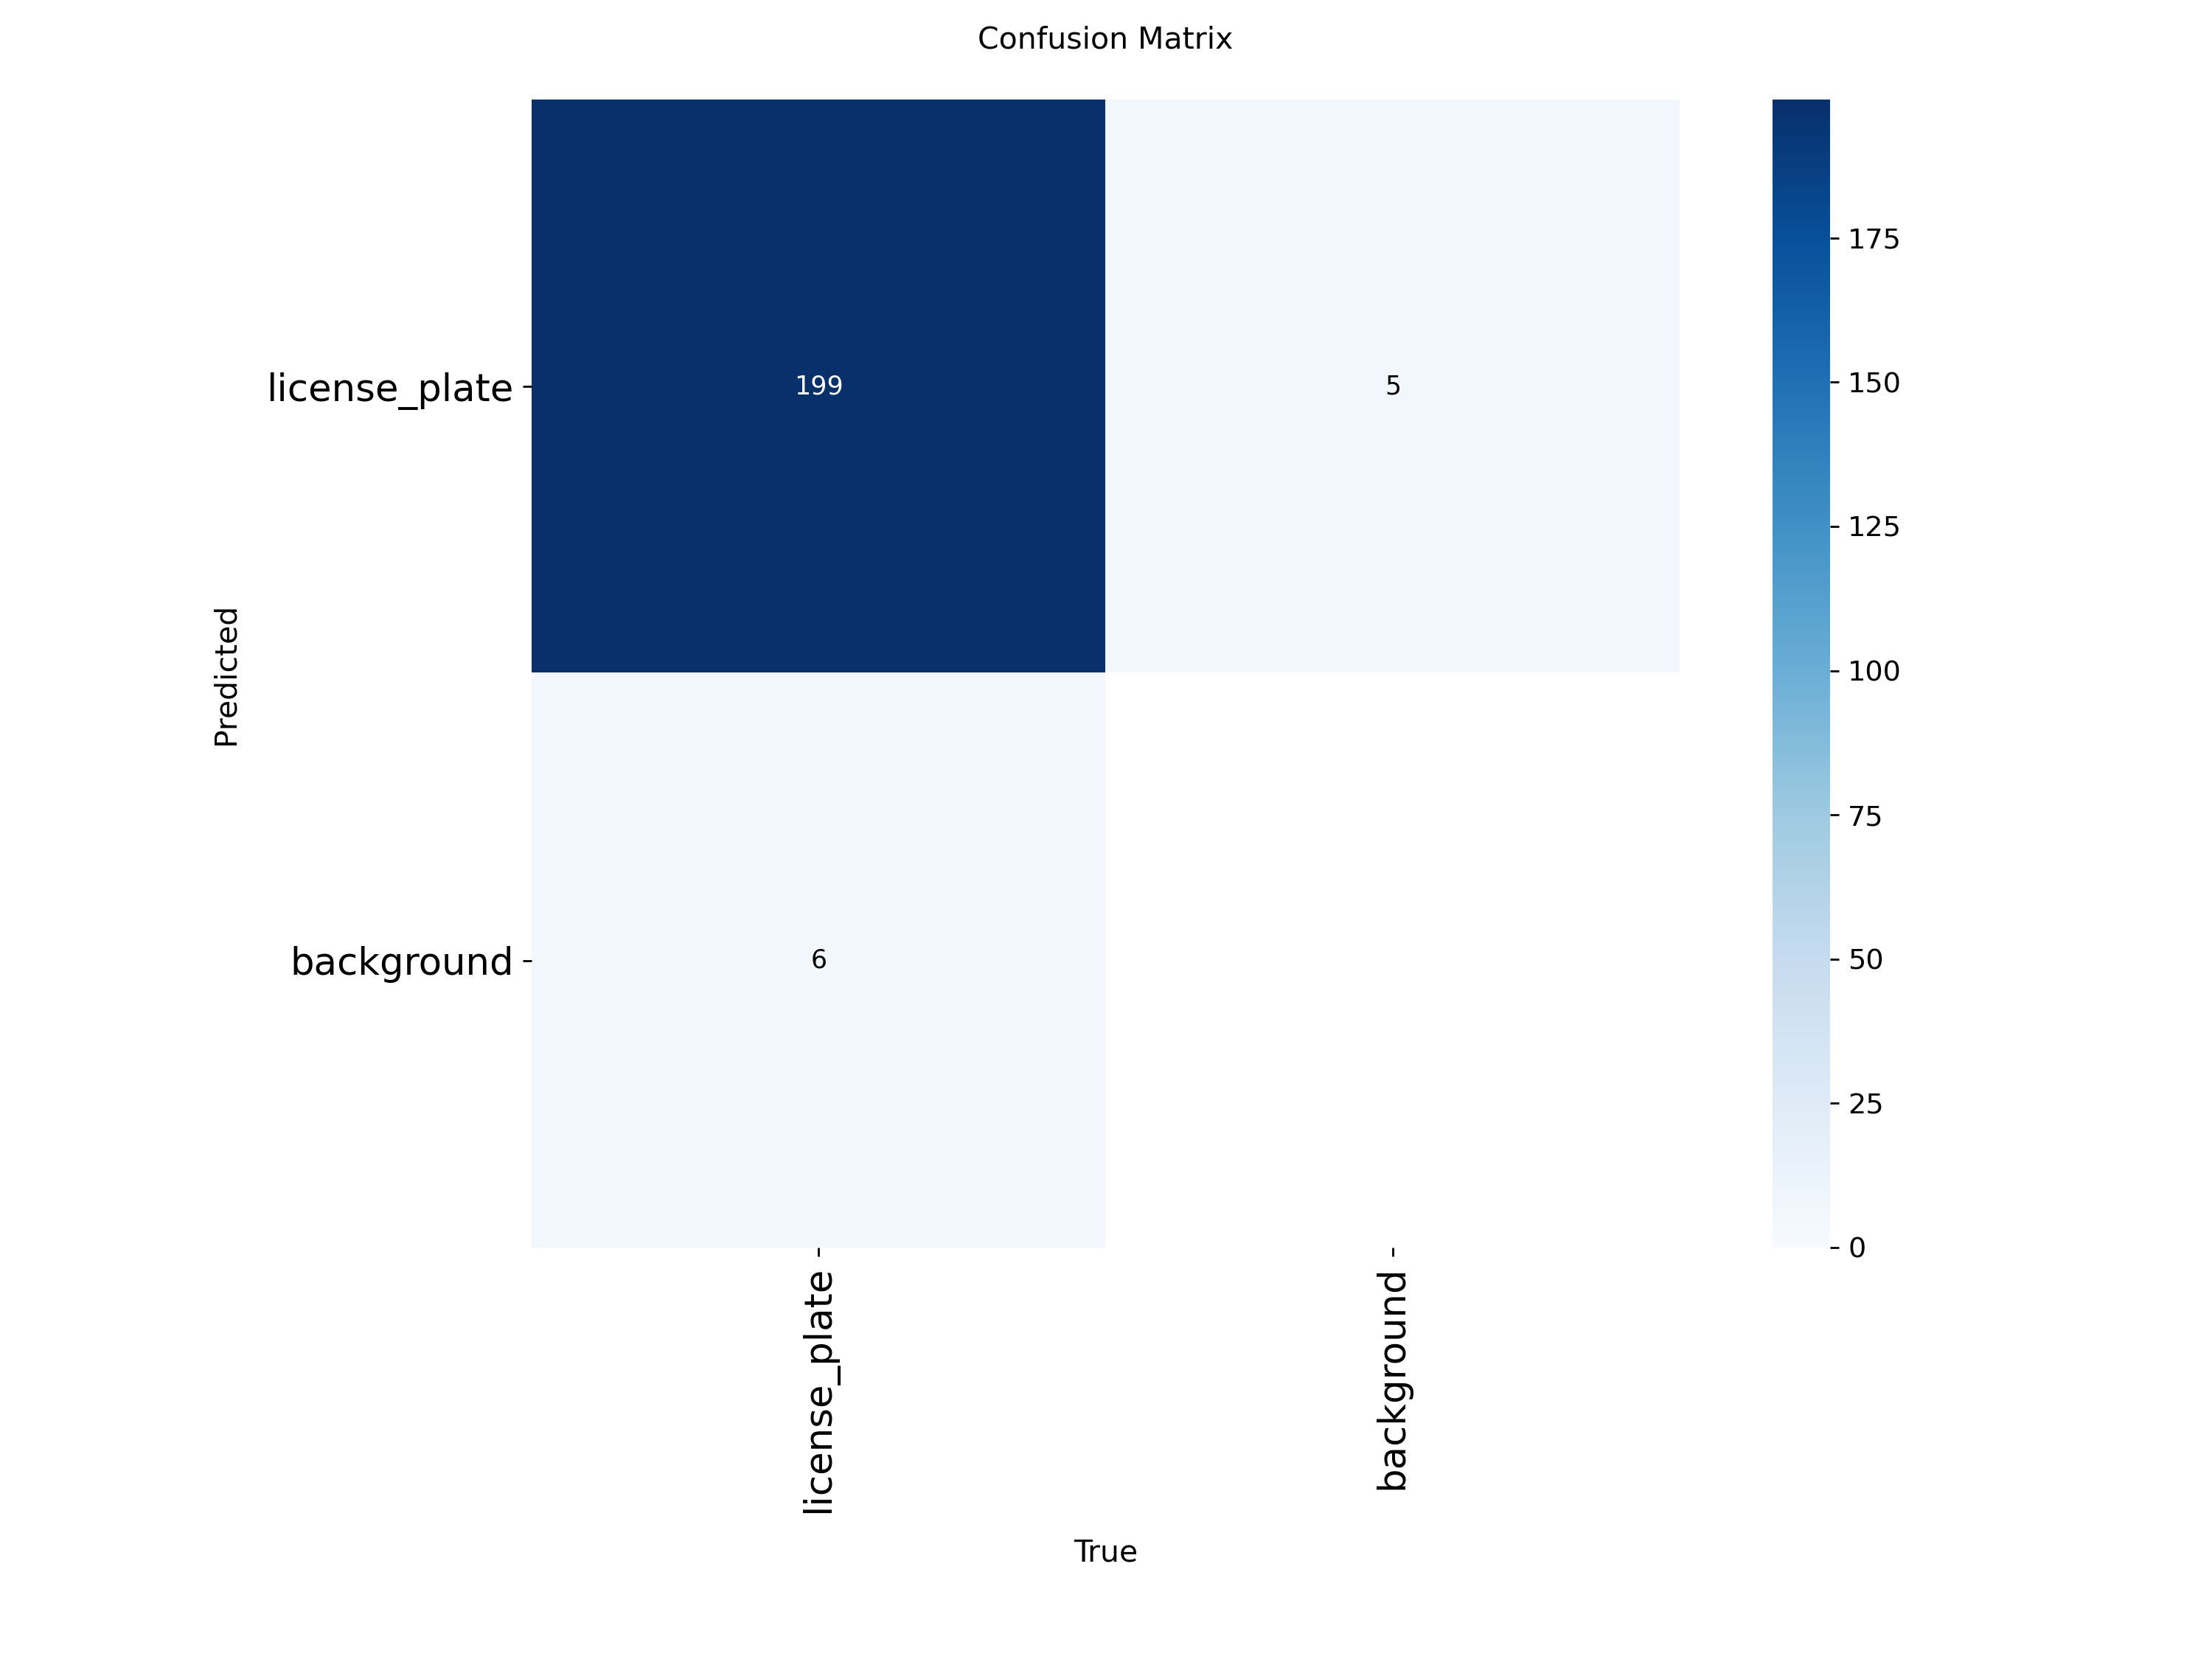


--- Running Inference ---
Testing on image: /content/license_plate_data/images/val/1604.jpg

image 1/1 /content/license_plate_data/images/val/1604.jpg: 256x320 1 license_plate, 45.5ms
Speed: 0.9ms preprocess, 45.5ms inference, 1.3ms postprocess per image at shape (1, 3, 256, 320)
Results saved to /content/runs/detect/ALPR_Inference/test_run

✅ Prediction Successful! Here is the result:


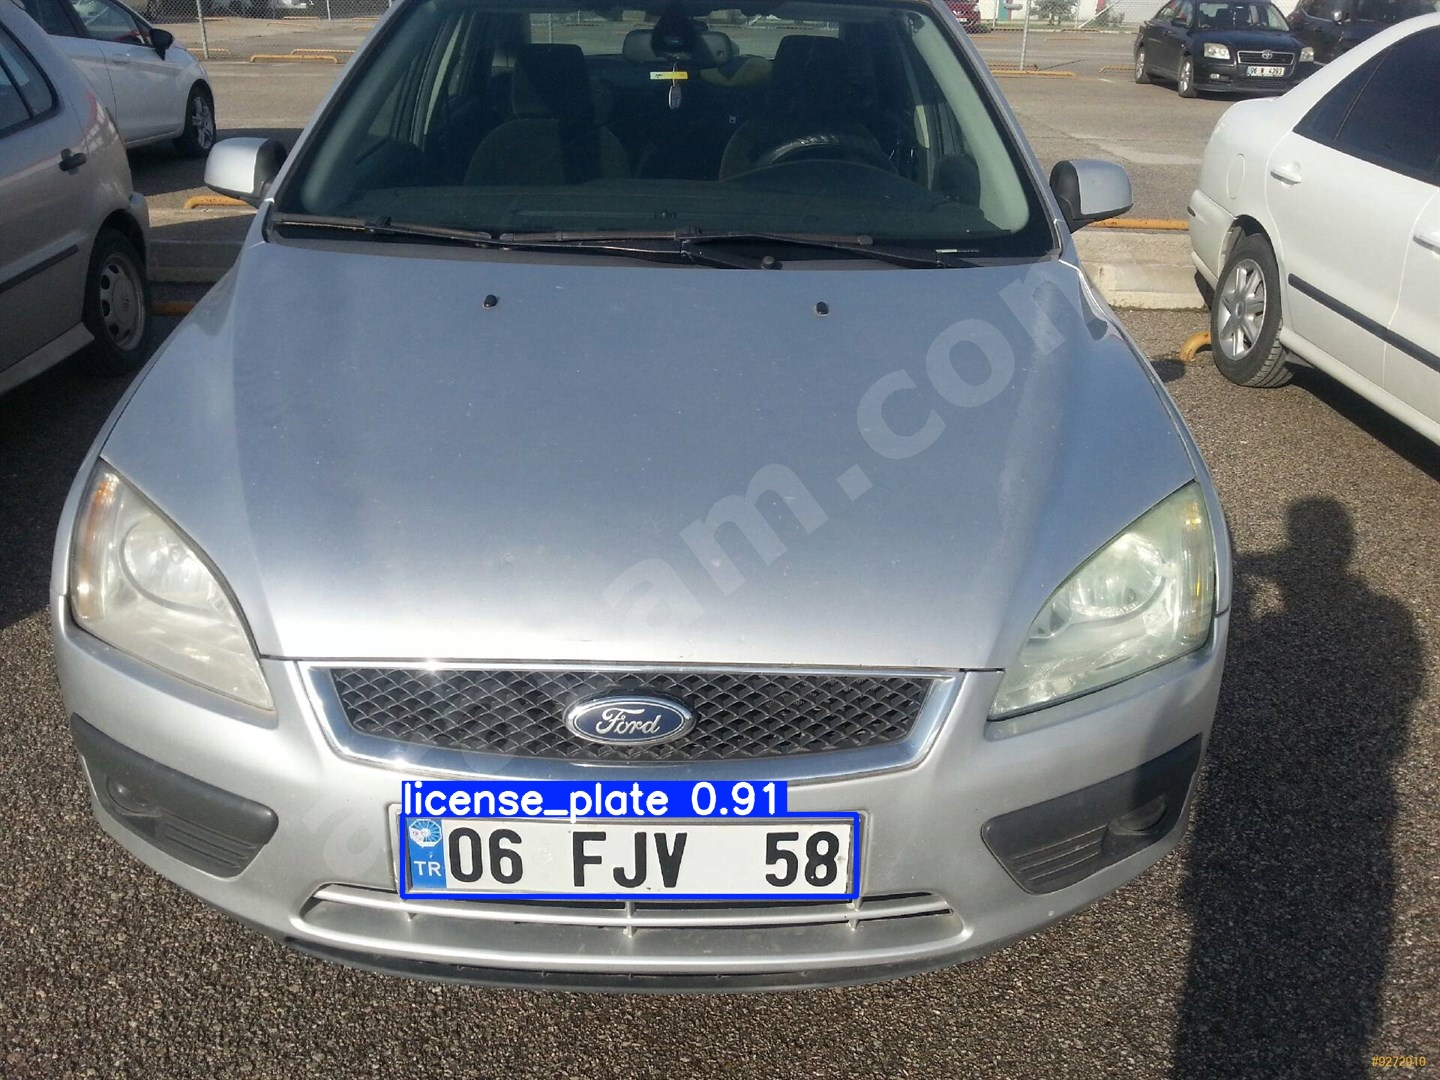

In [ ]:
import os
import glob
from IPython.display import Image, display
from ultralytics import YOLO
import random

print("--- Locating Latest Training Run ---")

# Find all 'best.pt' files in the correct YOLO directory
weight_files = glob.glob('runs/detect/ALPR_Edge/**/weights/best.pt', recursive=True)

if not weight_files:
    print("❌ ERROR: No weights found. Check the file paths!")
else:
    # Get the most recently modified weights file
    latest_weights = max(weight_files, key=os.path.getmtime)
    run_dir = os.path.dirname(os.path.dirname(latest_weights))

    print(f"✅ Found latest weights at: {latest_weights}")
    print(f"✅ Active run directory: {run_dir}\n")

    # Display Metrics
    print("--- Confusion Matrix ---")
    cm_path = os.path.join(run_dir, 'confusion_matrix.png')
    if os.path.exists(cm_path):
        display(Image(filename=cm_path, width=800))
    else:
        print("Confusion matrix not found.")

    # Load the dynamically found model
    print("\n--- Running Inference ---")
    # Load the model directly since we know exactly where it is now
custom_model = YOLO('runs/detect/ALPR_Edge/yolov8n_turkish_plates/weights/best.pt')

# Pick a random image
val_images = glob.glob('/content/license_plate_data/images/val/*.jpg')
if val_images:
    test_image_path = random.choice(val_images)
    print(f"Testing on image: {test_image_path}")

    # Run inference
    results = custom_model.predict(
        source=test_image_path,
        save=True,
        project='ALPR_Inference',
        name='test_run',
        exist_ok=True
    )
    save_dir = results[0].save_dir

    # Find the saved image
    predicted_image_path = glob.glob(f'{save_dir}/*.jpg')[0]

    # Display
    print("\n✅ Prediction Successful! Here is the result:")
    display(Image(filename=predicted_image_path, width=600))
else:
    print("❌ ERROR: No validation images found.")

           VISUAL TRAINING CURVES        

--- 1. Results Over 50 Epochs (results.png) ---
Top row: Training & Validation Losses (should go down).
Bottom row: Precision, Recall, and mAP (should go up).


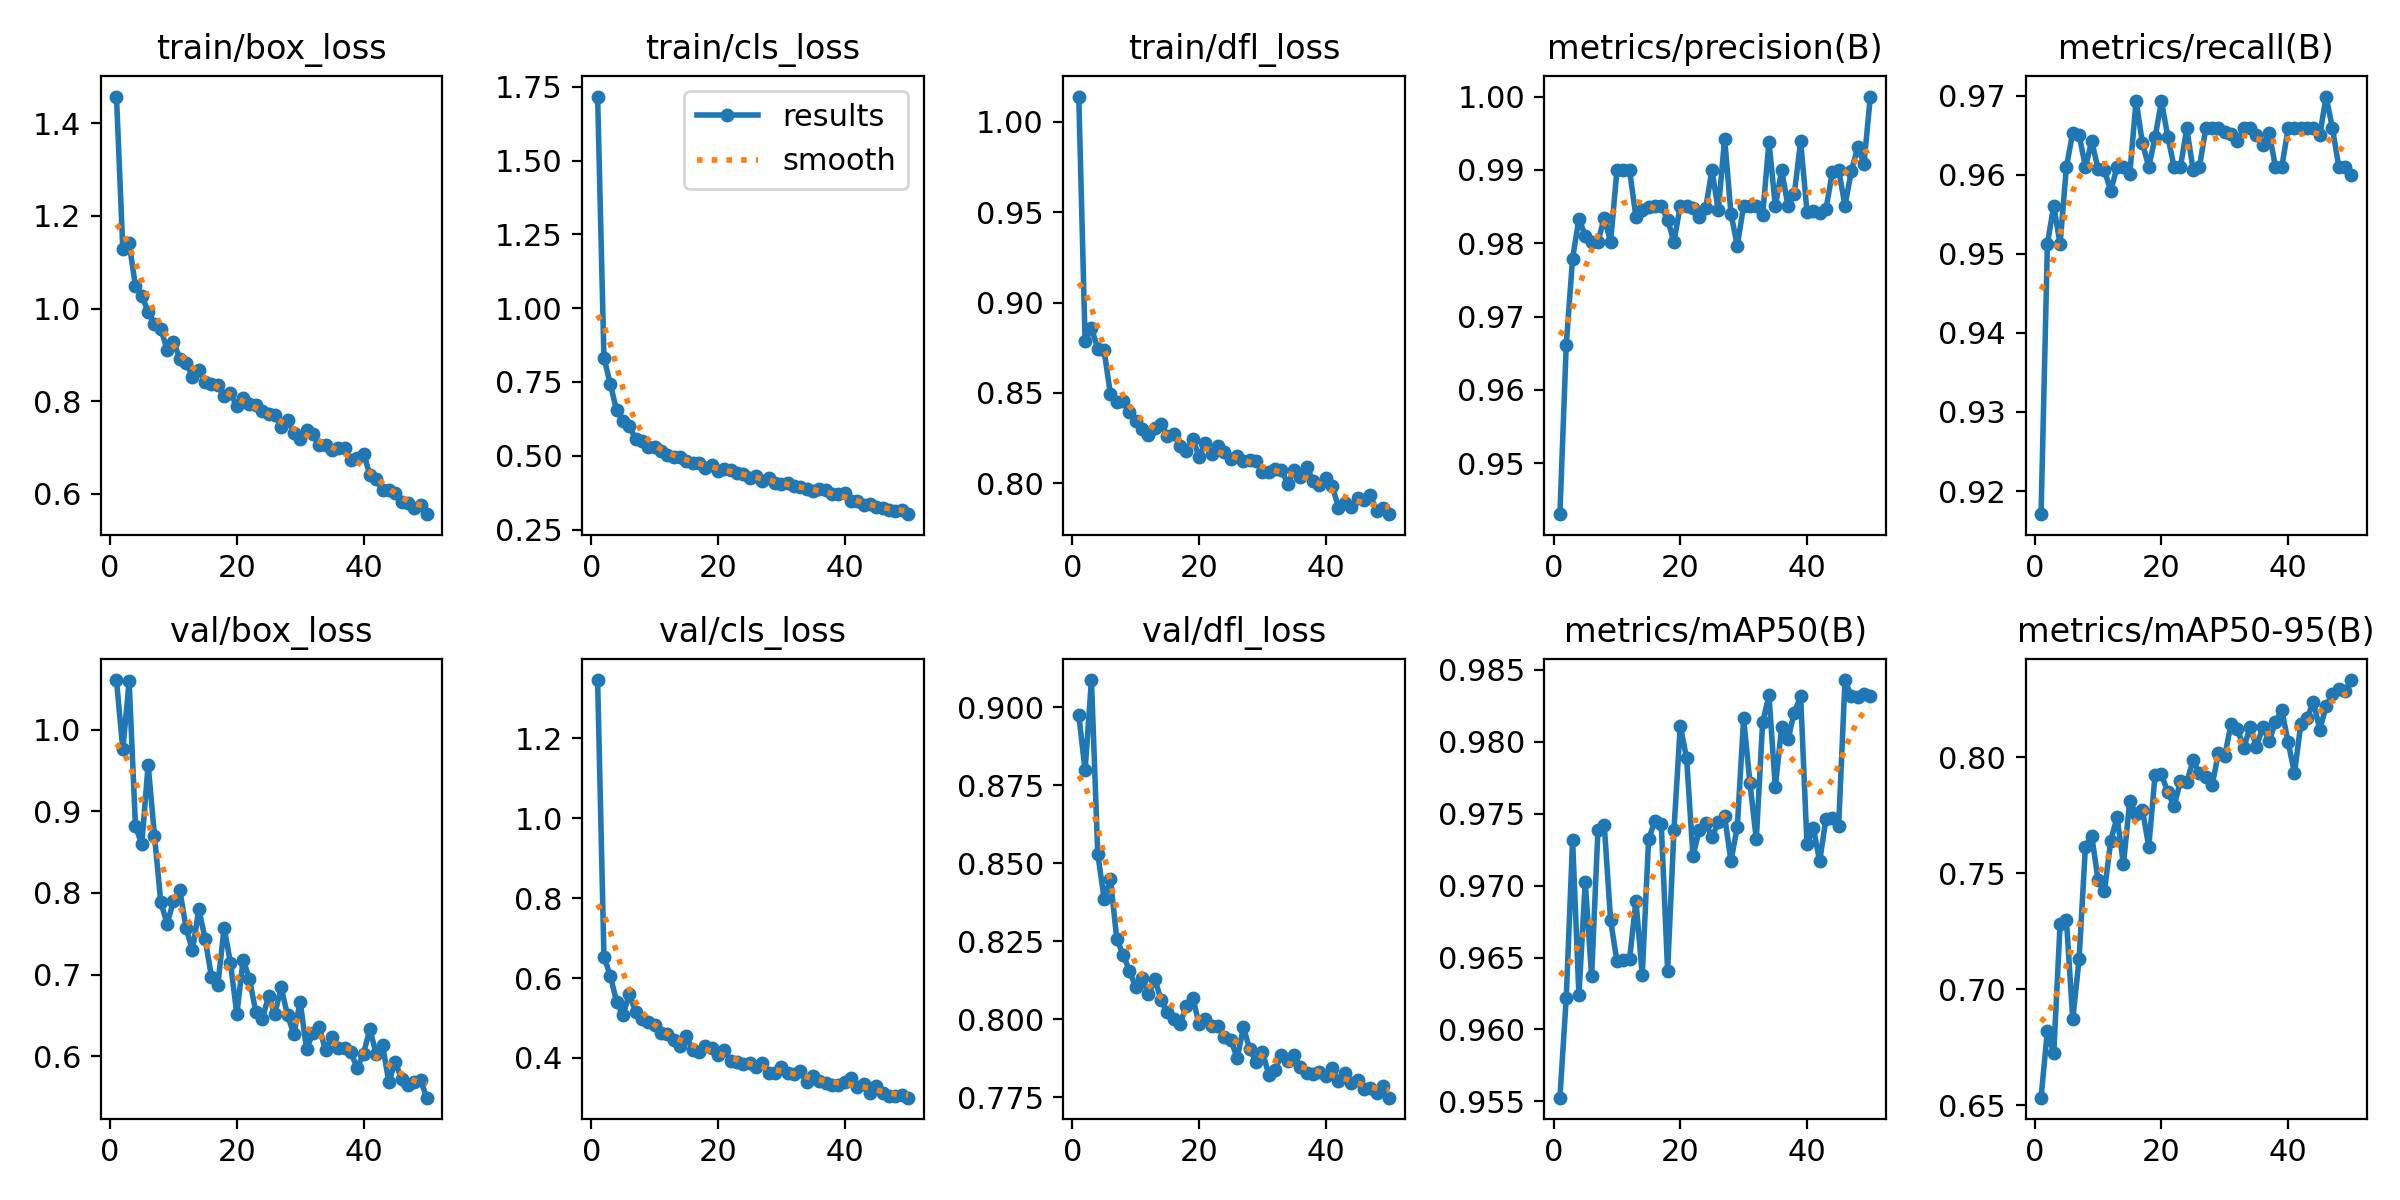


--- 2. F1 Score Curve (F1_curve.png) ---
Shows the optimal balance between Precision and Recall.

--- 3. Precision-Recall Curve (PR_curve.png) ---
A larger area under this curve means a highly accurate model.

           EXACT NUMERICAL METRICS       
Running a quick validation pass to grab the final numbers...

Ultralytics 8.4.42 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2902.7±836.6 MB/s, size: 2180.3 KB)
val: Scanning /content/license_plate_data/labels/val.cache... 196 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 196/196 43.3Mit/s 0.0s
val: /content/license_plate_data/images/val/153.jpg: corrupt JPEG restored and saved
val: /content/license_plate_data/images/val/183.jpg: corrupt JPEG restored and saved
val: /content/license_plate_data/images/val/237.jpg: corrupt JPEG restored and saved
val: /content/license_plate_data/images/

In [ ]:
import os
from IPython.display import Image, display
from ultralytics import YOLO

# Define the exact path to your successful training run
run_dir = 'runs/detect/ALPR_Edge/yolov8n_turkish_plates'

print("=========================================")
print("           VISUAL TRAINING CURVES        ")
print("=========================================")

# Display the Epoch Curves (Losses, Precision, Recall, mAP over time)
print("\n--- 1. Results Over 50 Epochs (results.png) ---")
print("Top row: Training & Validation Losses (should go down).")
print("Bottom row: Precision, Recall, and mAP (should go up).")
results_path = os.path.join(run_dir, 'results.png')
if os.path.exists(results_path):
    display(Image(filename=results_path, width=1000))
else:
    print("results.png not found.")

# Display the F1-Confidence Curve
print("\n--- 2. F1 Score Curve (F1_curve.png) ---")
print("Shows the optimal balance between Precision and Recall.")
f1_path = os.path.join(run_dir, 'F1_curve.png')
if os.path.exists(f1_path):
    display(Image(filename=f1_path, width=600))

# Display the Precision-Recall Curve
print("\n--- 3. Precision-Recall Curve (PR_curve.png) ---")
print("A larger area under this curve means a highly accurate model.")
pr_path = os.path.join(run_dir, 'PR_curve.png')
if os.path.exists(pr_path):
    display(Image(filename=pr_path, width=600))


print("\n=========================================")
print("           EXACT NUMERICAL METRICS       ")
print("=========================================")
print("Running a quick validation pass to grab the final numbers...\n")

# Load best weights
custom_model = YOLO(os.path.join(run_dir, 'weights', 'best.pt'))

# Run validation on the 'val' split quietly
metrics = custom_model.val(verbose=False)

# Extract the metrics for license plates
precision = metrics.results_dict['metrics/precision(B)']
recall = metrics.results_dict['metrics/recall(B)']
map50 = metrics.results_dict['metrics/mAP50(B)']
map50_95 = metrics.results_dict['metrics/mAP50-95(B)']

# Print them formatted as percentages
print(f"✅ Final Precision: {precision * 100:.2f}%")
print(f"✅ Final Recall:    {recall * 100:.2f}%")
print(f"✅ Final mAP@50:    {map50 * 100:.2f}%")
print(f"✅ Final mAP@50-95: {map50_95 * 100:.2f}%")

# ONNX Extraction


In [ ]:
from ultralytics import YOLO

# Load trained weights
custom_model = YOLO('runs/detect/ALPR_Edge/yolov8n_turkish_plates/weights/best.pt')

# Export to ONNX
# We keep the image size at 320 to match training, and dynamic=False for embedded NPU compatibility
export_path = custom_model.export(format='onnx', imgsz=320, opset=12, simplify=True, dynamic=False)

print(f"✅ ONNX export complete! File saved to: {export_path}")
print("You can download this .onnx file from the Colab file explorer on the left to keep it safe.")

Ultralytics 8.4.42 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from 'runs/detect/ALPR_Edge/yolov8n_turkish_plates/weights/best.pt' with input shape (1, 3, 320, 320) BCHW and output shape(s) (1, 5, 2100) (5.9 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 191ms
Prepared 4 packages in 7.26s
Installed 4 packages in 460ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime-gpu==1.25.1
 + onnxslim==0.1.91

requirements: AutoUpdate success ✅ 8.6s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 

# Crop The Image


image 1/1 /content/license_plate_data/images/val/380.jpg: 320x192 1 license_plate, 7.1ms
Speed: 0.9ms preprocess, 7.1ms inference, 1.2ms postprocess per image at shape (1, 3, 320, 192)
✅ License Plate Extracted:


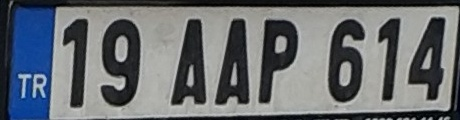

In [ ]:
import cv2
import glob
import random
from IPython.display import Image, display
from ultralytics import YOLO

custom_model = YOLO('runs/detect/ALPR_Edge/yolov8n_turkish_plates/weights/best.pt')

# Pick a random validation image
val_images = glob.glob('/content/license_plate_data/images/val/*.jpg')
test_image = random.choice(val_images)

# Run prediction
results = custom_model.predict(test_image)

# Extract the bounding box and crop the image
for result in results:
    boxes = result.boxes
    for box in boxes:
        # Get coordinates (x_min, y_min, x_max, y_max)
        x1, y1, x2, y2 = map(int, box.xyxy[0])

        # Load the original image using OpenCV
        img = cv2.imread(test_image)

        # Crop the image to just the license plate
        cropped_plate = img[y1:y2, x1:x2]

        # Save and display the cropped plate
        crop_path = 'cropped_plate.jpg'
        cv2.imwrite(crop_path, cropped_plate)

        print("✅ License Plate Extracted:")
        display(Image(filename=crop_path))

# Read The Image

--- Starting Character Segmentation ---


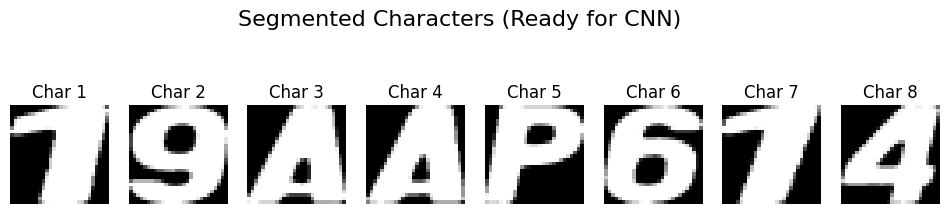

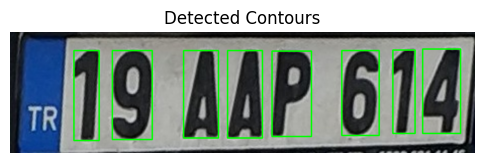

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("--- Starting Character Segmentation ---")

# Load the cropped plate image
img = cv2.imread('cropped_plate.jpg')

# Resize the image to make contour detection easier (Optional but helpful)
img = cv2.resize(img, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)

# Convert to Grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Blur slightly to remove tiny noise (like screws or dirt on the plate)
blur = cv2.GaussianBlur(gray, (5,5), 0)

# Thresholding (Binarization)
# Otsu's thresholding automatically calculates the best cutoff point between black and white
_, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Find contours (the outlines of the white shapes on our black background)
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

char_boxes = []
char_images = []

# Filter contours to only keep things that look like letters/numbers
for c in contours:
    x, y, w, h = cv2.boundingRect(c)
    aspect_ratio = w / float(h)

    # A standard character is taller than it is wide, and shouldn't be microscopic
    if 0.15 < aspect_ratio < 0.9 and h > 20:
        char_boxes.append((x, y, w, h))

# Sort the boxes from left to right (so we read "34" before "ABC")
char_boxes = sorted(char_boxes, key=lambda b: b[0])

output_img = img.copy()

# Create a matplotlib figure to show the sliced characters
fig, axes = plt.subplots(1, len(char_boxes), figsize=(12, 3))
if len(char_boxes) == 1:
    axes = [axes] # Handle edge case of only 1 character found

for i, box in enumerate(char_boxes):
    x, y, w, h = box

    # Draw a green box around the character on the original image for visualization
    cv2.rectangle(output_img, (x, y), (x+w, y+h), (0, 255, 0), 2)

    # Crop the exact character out of the thresholded (black and white) image
    char_crop = thresh[y:y+h, x:x+w]

    # We resize it to 28x28 pixels because that is the standard size for tiny CNNs
    char_resized = cv2.resize(char_crop, (28, 28), interpolation=cv2.INTER_AREA)
    char_images.append(char_resized)

    # Display the slice
    axes[i].imshow(char_resized, cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(f"Char {i+1}")

plt.suptitle("Segmented Characters (Ready for CNN)", fontsize=16)
plt.show()

# Show the original image with bounding boxes
plt.figure(figsize=(6,3))
plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
plt.title("Detected Contours")
plt.axis('off')
plt.show()

# EMNIST (Number/Letter Detection) CNN

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

print("--- 1. Prepping EMNIST Dataset ---")
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.transpose(1, 2))
])

train_dataset = torchvision.datasets.EMNIST(root='./data', split='balanced', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

# Define the Tiny CNN again just to be safe
class TinyOCR(nn.Module):
    def __init__(self, num_classes):
        super(TinyOCR, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 32 * 7 * 7)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = TinyOCR(num_classes=47).to(device)
criterion = nn.CrossEntropyLoss()

# We add a Learning Rate Scheduler here
optimizer = optim.Adam(model.parameters(), lr=0.002)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=4, gamma=0.5)

print("\n--- 2. Training the Tiny CNN (12 Epochs) ---")
epochs = 36
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, data in enumerate(train_loader, 0):
        inputs, labels = data[0].to(device), data[1].to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    # Step the scheduler to lower the learning rate
    scheduler.step()

    accuracy = 100 * correct / total
    current_lr = scheduler.get_last_lr()[0]
    print(f"Epoch {epoch+1}/{epochs} | Loss: {running_loss/len(train_loader):.4f} | Acc: {accuracy:.2f}% | LR: {current_lr:.5f}")

print("\n--- 3. Exporting Upgraded Model to ONNX ---")
model.eval()
dummy_input = torch.randn(1, 1, 28, 28, device=device)
onnx_path = "tiny_ocr_model.onnx"

torch.onnx.export(
    model,
    dummy_input,
    onnx_path,
    export_params=True,
    opset_version=12,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}}
)

print(f"✅ Upgraded OCR ONNX export complete! Saved as: {onnx_path}")

--- 1. Prepping EMNIST Dataset ---

--- 2. Training the Tiny CNN (12 Epochs) ---
Epoch 1/36 | Loss: 0.8222 | Acc: 74.63% | LR: 0.00200
Epoch 2/36 | Loss: 0.4473 | Acc: 84.75% | LR: 0.00200
Epoch 3/36 | Loss: 0.3919 | Acc: 86.28% | LR: 0.00200
Epoch 4/36 | Loss: 0.3585 | Acc: 87.20% | LR: 0.00100
Epoch 5/36 | Loss: 0.3042 | Acc: 88.97% | LR: 0.00100
Epoch 6/36 | Loss: 0.2912 | Acc: 89.25% | LR: 0.00100
Epoch 7/36 | Loss: 0.2784 | Acc: 89.66% | LR: 0.00100
Epoch 8/36 | Loss: 0.2672 | Acc: 89.95% | LR: 0.00050
Epoch 9/36 | Loss: 0.2376 | Acc: 91.07% | LR: 0.00050
Epoch 10/36 | Loss: 0.2295 | Acc: 91.37% | LR: 0.00050
Epoch 11/36 | Loss: 0.2230 | Acc: 91.51% | LR: 0.00050
Epoch 12/36 | Loss: 0.2176 | Acc: 91.71% | LR: 0.00025
Epoch 13/36 | Loss: 0.2008 | Acc: 92.41% | LR: 0.00025
Epoch 14/36 | Loss: 0.1965 | Acc: 92.53% | LR: 0.00025
Epoch 15/36 | Loss: 0.1929 | Acc: 92.60% | LR: 0.00025
Epoch 16/36 | Loss: 0.1902 | Acc: 92.74% | LR: 0.00013
Epoch 17/36 | Loss: 0.1811 | Acc: 93.13% | LR: 0

ModuleNotFoundError: No module named 'onnxscript'

# Combining Both

      END-TO-END ALPR PIPELINE TEST      
Testing on image: /content/license_plate_data/images/val/432.jpg



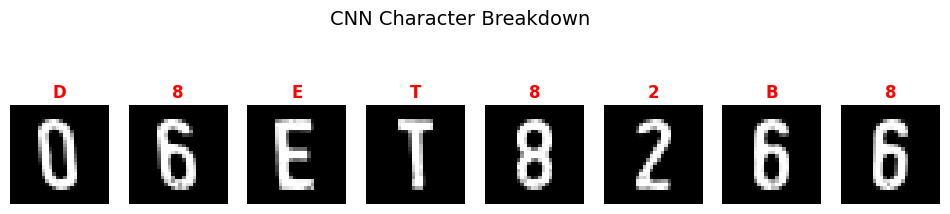

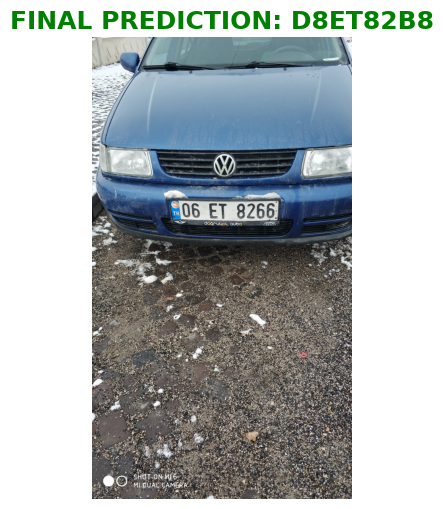


✅ JSON PAYLOAD DATA READY: 'D8ET82B8'


In [ ]:
import cv2
import torch
import glob
import random
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
import torchvision.transforms.functional as TF

print("=========================================")
print("      END-TO-END ALPR PIPELINE TEST      ")
print("=========================================")

# Setup Models
yolo_model = YOLO('runs/detect/ALPR_Edge/yolov8n_turkish_plates/weights/best.pt')
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.eval()
emnist_chars = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabdefghnqrt"

# Pick a random test image
val_images = glob.glob('/content/license_plate_data/images/val/*.jpg')
test_image_path = random.choice(val_images)
print(f"Testing on image: {test_image_path}\n")

# Detect Plate
results = yolo_model.predict(source=test_image_path, verbose=False)
img = cv2.imread(test_image_path)
final_plate_text = ""

if len(results[0].boxes) > 0:
    box = results[0].boxes[0]
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    cropped_plate = img[y1:y2, x1:x2]

    # Segment Characters
    cropped_plate = cv2.resize(cropped_plate, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
    gray = cv2.cvtColor(cropped_plate, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5,5), 0)
    _, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    char_boxes = []
    for c in contours:
        x, y, w, h = cv2.boundingRect(c)
        aspect_ratio = w / float(h)
        if 0.15 < aspect_ratio < 0.9 and h > 20:
            char_boxes.append((x, y, w, h))

    char_boxes = sorted(char_boxes, key=lambda b: b[0])

    fig, axes = plt.subplots(1, max(1, len(char_boxes)), figsize=(12, 3))
    if len(char_boxes) == 1: axes = [axes]

    # Read Characters
    for i, box in enumerate(char_boxes):
        x, y, w, h = box
        char_crop = thresh[y:y+h, x:x+w]

        if char_crop.size == 0: continue

        # Centering and padding logic
        h_c, w_c = char_crop.shape
        max_dim = max(h_c, w_c)
        scale = 20.0 / max_dim
        new_w, new_h = int(w_c * scale), int(h_c * scale)
        new_w, new_h = max(1, new_w), max(1, new_h)

        char_scaled = cv2.resize(char_crop, (new_w, new_h), interpolation=cv2.INTER_AREA)
        char_resized = np.zeros((28, 28), dtype=np.uint8)

        start_x = (28 - new_w) // 2
        start_y = (28 - new_h) // 2
        char_resized[start_y:start_y+new_h, start_x:start_x+new_w] = char_scaled

        char_tensor = TF.to_tensor(char_resized)

        char_tensor = char_tensor.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(char_tensor)
            _, predicted = torch.max(output.data, 1)
            predicted_char = emnist_chars[predicted.item()]
            final_plate_text += predicted_char.upper()

        if i < len(axes):
            axes[i].imshow(char_resized, cmap='gray')
            axes[i].axis('off')
            axes[i].set_title(predicted_char.upper(), color='red', fontweight='bold')

    plt.suptitle(f"CNN Character Breakdown", fontsize=14)
    plt.show()

    plt.figure(figsize=(8,6))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"FINAL PREDICTION: {final_plate_text}", fontsize=18, color='green', fontweight='bold')
    plt.axis('off')
    plt.show()

    print(f"\n✅ JSON PAYLOAD DATA READY: '{final_plate_text}'")

else:
    print("❌ No license plate detected in this image.")